<div style="background:linear-gradient(135deg,#4c1d95 0%,#6d28d9 55%,#a78bfa 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#ddd6fe;font-weight:700;text-transform:uppercase">Chapter 192 &middot; Capstone 30 &middot; Explainability</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Churn Prediction and Who Is Worth Contacting</div>
  <div style="font-size:15px;color:#ddd6fe;max-width:820px;line-height:1.6">Three models land within a thousandth of each other on AUC. Switching from the best one to the worst costs almost nothing. Switching from targeting by risk to targeting by uplift is worth twice the money, and the highest-risk subscribers turn out to be the worst people to contact.</div>
</div>

In [1]:
import numpy as np, pandas as pd, warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
VI, DK, LT, MUT, GD, RD = "#6d28d9", "#4c1d95", "#a78bfa", "#94a3b8", "#047857", "#dc2626"

MARGIN, OFFER = 290.0, 30.0     # dollars of annual gross margin saved; dollars per offer sent

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-churn-prediction-explainability.xlsx"
def load(sheet):
    try:    return pd.read_excel("../../data/" + fn, sheet_name=sheet)
    except FileNotFoundError: return pd.read_excel(BASE + fn, sheet_name=sheet)
raw   = load("Data")
notes = load("Notes")
print("rows in the export:", f"{len(raw):,}")
raw.head()

rows in the export: 24,380


,subscriber_id,tenure_months,plan_size,boxes_per_month,avg_order_value,signup_discount,signup_channel,region,delivery_issues_90d,support_contacts_90d,last_rating,skips_90d,app_logins_30d,payment_failures_90d,autopay,retention_offer,churned_90d
0,519810,24,3,4.2,64.50,0,referral,Northeast,2,4,3,0,7,0,0,0,1
1,519897,29,2,1.2,45.07,0,social,West,0,0,4,1,6,0,1,0,0
2,520720,2,3,4.3,67.43,0,social,South,2,0,4,1,2,0,0,0,1
3,520071,7,3,1.9,66.18,0,search,West,1,1,4,1,8,0,0,0,0
4,505800,24,4,2.3,85.65,0,social,South,1,3,2,2,3,0,0,0,0


## Step 1 &middot; The brief, and the arithmetic that decides everything

A meal-kit company ran a retention campaign last quarter. Half of all active subscribers, chosen at random, were sent a "20 percent off your next three boxes" offer. The other half were sent nothing. We have the outcomes.

The retention team wants a model that tells them who to send it to **next** quarter. That sounds like a churn model, and it is not.

In [2]:
for line in notes.Notes.fillna(""):
    print(line)

CAPSTONE 30 - SUBSCRIPTION CHURN, EXPLAINABILITY AND RETENTION ECONOMICS

One quarter of subscriber records from a meal-kit company, with the outcome of a
randomized retention campaign attached.

THE CAMPAIGN. Half of all active subscribers were selected at random and sent a
'20 percent off your next three boxes' offer. The other half were sent nothing. The
assignment was made by a coin flip on the account number, so the two groups are
comparable on everything, measured or not.

THE ECONOMICS, agreed with the retention team before any modeling:
  gross margin of a retained subscriber over the following year   = 290 dollars
  cost of the offer, per targeted account                          = 30 dollars
  the offer credit is applied to the account whether or not the subscriber
  would have stayed anyway, so it is a cost of TARGETING, not a cost of SAVING.

THE QUESTION. Not 'who is most likely to cancel'. The question is 'who should we
send the offer to next quarter', and those are diffe

Two numbers do all the work here.

A retained subscriber is worth **290 dollars** of gross margin over the following year. The offer costs **30 dollars** per account it is sent to, and that credit lands on the account whether or not the subscriber was ever going to leave. So the offer is a cost of **targeting**, not a cost of **saving**.

Divide one by the other and you get the number the whole project turns on:

$$\text{break-even uplift} = \frac{30}{290} = 0.1034$$

Sending the offer to somebody is worth doing only if it lowers **their** chance of cancelling by more than **10.3 percentage points**. Not if they are likely to cancel. If it *changes* whether they cancel, by at least that much.

## Step 2 &middot; Cleaning, and the three faults in the export

In [3]:
d = raw.drop_duplicates(subset="subscriber_id").copy()
print(f"raw rows                     {len(raw):,}")
print(f"after the duplicated export  {len(d):,}")

# -1 in last_rating means "never rated a box". It is not a missing value marker pandas knows about,
# and left alone it would be read as a rating far below 1.
d["never_rated"] = (d.last_rating == -1).astype(int)
d.loc[d.last_rating == -1, "last_rating"] = np.nan
d["last_rating"] = d.last_rating.fillna(d.last_rating.median())
print(f"accounts that never rated    {int(d.never_rated.sum()):,}  (flagged, rating filled with the median)")

# tenure 0 means the account opened inside the window, so a 90 day churn was impossible
d = d[d.tenure_months > 0].copy()
print(f"eligible for a 90 day churn  {len(d):,}")
print()
print(f"churn rate                   {d.churned_90d.mean():.4f}")
print(f"offered / not offered        {int(d.retention_offer.sum()):,} / {int((1-d.retention_offer).sum()):,}")

raw rows                     24,380
after the duplicated export  24,000
accounts that never rated    405  (flagged, rating filled with the median)
eligible for a 90 day churn  23,641

churn rate                   0.1966
offered / not offered        11,917 / 11,724


That last exclusion matters more than it looks. Those 359 accounts have `churned_90d = 0` **by construction**, not because they were happy. Leaving them in would teach the model that a very short tenure predicts staying, which is the opposite of the truth.

## Step 3 &middot; First look

The campaign, the model and the segments all come later. First, who is on this file and who leaves.

In [4]:
print(f"{len(d):,} subscribers, {int(d.churned_90d.sum()):,} churned in 90 days "
      f"({d.churned_90d.mean():.1%})")

print("\nCHURN BY TENURE")
b = pd.cut(d.tenure_months, [0, 3, 6, 12, 24, 100], right=False)
t = d.groupby(b, observed=True).churned_90d.agg(["size", "mean"])
for iv, row in t.iterrows():
    print(f"  tenure {str(iv):10s} n {int(row['size']):6,}   churn {row['mean']:6.1%}")

print("\nHOW CHURNERS DIFFER FROM THE REST")
print(f"  {'feature':24s}{'stayed':>11}{'churned':>11}{'std diff':>11}")
for c in ["tenure_months", "boxes_per_month", "avg_order_value", "signup_discount",
          "delivery_issues_90d", "support_contacts_90d", "last_rating", "skips_90d",
          "app_logins_30d", "payment_failures_90d", "autopay"]:
    a, b2 = d.loc[d.churned_90d == 0, c], d.loc[d.churned_90d == 1, c]
    smd = (b2.mean() - a.mean())/np.sqrt((a.var() + b2.var())/2)
    print(f"  {c:24s}{a.mean():>11,.2f}{b2.mean():>11,.2f}{smd:>+11.3f}")

23,641 subscribers, 4,647 churned in 90 days (19.7%)

CHURN BY TENURE
  tenure [0, 3)     n  1,124   churn  43.6%
  tenure [3, 6)     n  3,243   churn  32.7%
  tenure [6, 12)    n  7,139   churn  19.3%
  tenure [12, 24)   n  8,451   churn  15.5%
  tenure [24, 100)  n  3,684   churn  11.1%

HOW CHURNERS DIFFER FROM THE REST
  feature                      stayed    churned   std diff
  tenure_months                 14.85      10.85     -0.433
  boxes_per_month                2.86       2.75     -0.118
  avg_order_value               61.61      63.22     +0.107
  signup_discount                0.40       0.49     +0.197
  delivery_issues_90d            0.57       1.27     +0.770
  support_contacts_90d           0.58       1.21     +0.536
  last_rating                    4.07       3.36     -0.818
  skips_90d                      1.76       2.42     +0.442
  app_logins_30d                 5.13       4.19     -0.371
  payment_failures_90d           0.05       0.09     +0.161
  autopay      

**What this shows.** About one subscriber in five leaves within ninety days, and churn is concentrated in the first few months: 44 percent in the first two, down to 11 percent past two years. An account opened last quarter is a different animal from one opened two years ago, and any model built here will spend much of its capacity learning that.

The comparison table gives the shape of the rest. The last rating a subscriber gave moves most, at over four fifths of a standard deviation, followed closely by delivery issues, then support contacts and skipped boxes. App logins move the other way. None of that is causal, and the distance between predicting who leaves and knowing what to do about it is the subject of the second half of this notebook.

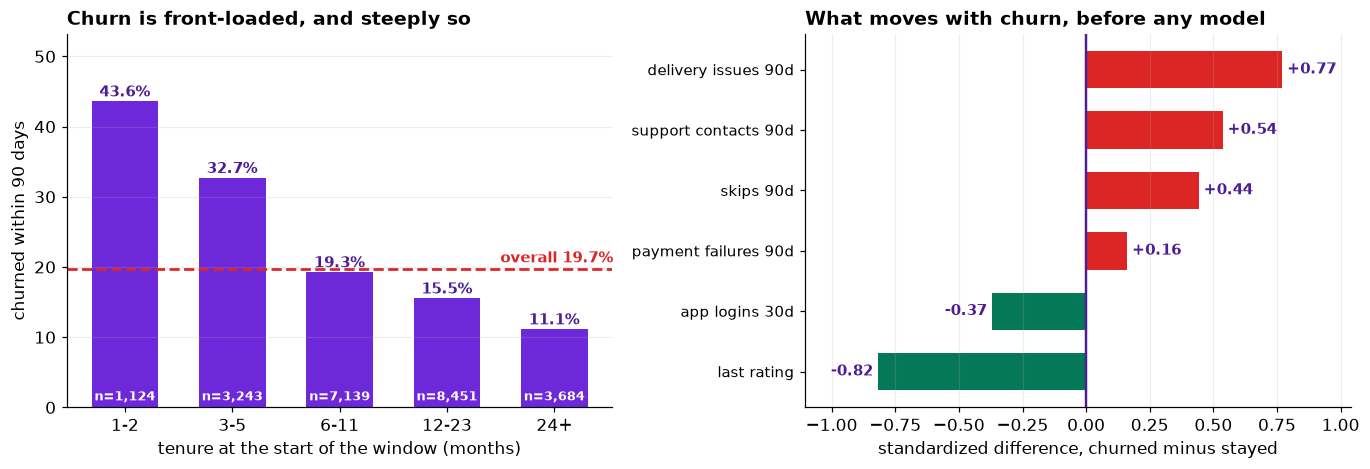

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

ax = axes[0]
b = pd.cut(d.tenure_months, [0, 3, 6, 12, 24, 100], right=False)
lab = ["1-2", "3-5", "6-11", "12-23", "24+"]
t = d.groupby(b, observed=True).churned_90d.agg(["size", "mean"])
xp = np.arange(len(lab))
ax.bar(xp, t["mean"].values*100, color=VI, width=0.62)
for x, v_, n_ in zip(xp, t["mean"].values*100, t["size"].values):
    ax.text(x, v_ + 0.7, f"{v_:.1f}%", ha="center", fontsize=10, fontweight="bold", color=DK)
    ax.text(x, 1.0, f"n={n_:,}", ha="center", fontsize=8.5, color="white", fontweight="bold")
ax.axhline(d.churned_90d.mean()*100, color=RD, lw=1.8, ls="--")
ax.text(len(lab)-0.45, d.churned_90d.mean()*100 + 1.0,
        f"overall {d.churned_90d.mean():.1%}", ha="right", fontsize=9.5,
        fontweight="bold", color=RD)
ax.set_xticks(xp); ax.set_xticklabels(lab)
ax.set_ylim(0, t["mean"].max()*100*1.22)
ax.set_xlabel("tenure at the start of the window (months)")
ax.set_ylabel("churned within 90 days")
ax.set_title("Churn is front-loaded, and steeply so")
ax.grid(axis="x", alpha=0)

ax = axes[1]
feats = ["skips_90d", "support_contacts_90d", "delivery_issues_90d",
         "payment_failures_90d", "app_logins_30d", "last_rating"]
smd = []
for c in feats:
    a, b2 = d.loc[d.churned_90d == 0, c], d.loc[d.churned_90d == 1, c]
    smd.append((b2.mean() - a.mean())/np.sqrt((a.var() + b2.var())/2))
order = np.argsort(smd)
cols = [RD if smd[i] > 0 else GD for i in order]
ax.barh(range(len(feats)), [smd[i] for i in order], color=cols, height=0.62)
ax.set_yticks(range(len(feats)))
ax.set_yticklabels([feats[i].replace("_", " ") for i in order], fontsize=9.5)
for i, v_ in enumerate([smd[j] for j in order]):
    ax.text(v_ + (0.02 if v_ > 0 else -0.02), i, f"{v_:+.2f}", va="center",
            ha="left" if v_ > 0 else "right", fontsize=9.5, fontweight="bold", color=DK)
ax.axvline(0, color=DK, lw=1.6)
ax.set_xlim(min(smd)*1.35, max(smd)*1.35)
ax.set_xlabel("standardized difference, churned minus stayed")
ax.set_title("What moves with churn, before any model")
ax.grid(axis="y", alpha=0)
plt.tight_layout(); plt.show()

**Left:** the first two months carry churn four times the rate of the two-year cohort. **Right:** a low last rating and a run of delivery issues are the two things that most distinguish leavers, and logging into the app points the other way. Read this as a description of the file and not as a list of levers. Every one of these is measured over the same ninety days as the churn it is lined up against, so each is at least as likely to be a symptom of leaving as a cause of it.

## Step 4 &middot; Check the randomization before trusting anything

The campaign was randomized, which is the reason this dataset can answer a causal question at all. Randomization is a claim about how the assignment was made, and claims are worth checking.

In [6]:
num = ["tenure_months","plan_size","boxes_per_month","avg_order_value","signup_discount",
       "delivery_issues_90d","support_contacts_90d","last_rating","skips_90d",
       "app_logins_30d","payment_failures_90d","autopay","never_rated"]
print(f"{'feature':24s} {'offered':>9s} {'control':>9s} {'std diff':>10s}")
worst = 0
for c in num:
    a, b = d.loc[d.retention_offer==1, c], d.loc[d.retention_offer==0, c]
    smd = (a.mean()-b.mean())/np.sqrt((a.var()+b.var())/2)
    worst = max(worst, abs(smd))
    print(f"{c:24s} {a.mean():9.3f} {b.mean():9.3f} {smd:+10.4f}")
print(f"\nlargest absolute standardized difference: {worst:.4f}")
print("Anything under 0.10 is conventionally called balanced. Nothing here is close to it.")

feature                    offered   control   std diff
tenure_months               14.132    14.001    +0.0134
plan_size                    2.735     2.742    -0.0091
boxes_per_month              2.834     2.848    -0.0151
avg_order_value             61.869    61.991    -0.0082
signup_discount              0.420     0.413    +0.0147
delivery_issues_90d          0.713     0.700    +0.0151
support_contacts_90d         0.704     0.704    +0.0002
last_rating                  3.927     3.934    -0.0076
skips_90d                    1.885     1.893    -0.0053


app_logins_30d               4.930     4.958    -0.0107
payment_failures_90d         0.054     0.055    -0.0009
autopay                      0.678     0.669    +0.0179
never_rated                  0.016     0.018    -0.0133

largest absolute standardized difference: 0.0179
Anything under 0.10 is conventionally called balanced. Nothing here is close to it.


## Step 5 &middot; The campaign as it was actually run

Before modeling anything, price what already happened. This is a randomized comparison, so the difference in churn between the two arms is the causal effect of the offer, and no model is needed to get it.

In [7]:
t = d.loc[d.retention_offer==1, "churned_90d"]
c = d.loc[d.retention_offer==0, "churned_90d"]
ate = t.mean() - c.mean()
se  = np.sqrt(t.var(ddof=1)/len(t) + c.var(ddof=1)/len(c))
lo, hi = ate - 1.96*se, ate + 1.96*se

print(f"churn, offered      {t.mean():.4f}   (n = {len(t):,})")
print(f"churn, not offered  {c.mean():.4f}   (n = {len(c):,})")
print(f"effect of the offer {ate*100:+.2f} pp     95% CI [{lo*100:+.2f}, {hi*100:+.2f}]")
print()
per = -ate*MARGIN - OFFER
print("THE MONEY, per account the offer was sent to:")
print(f"  margin saved   {-ate:.4f} x ${MARGIN:,.0f}  = ${-ate*MARGIN:8,.2f}")
print(f"  offer cost                          = ${-OFFER:8,.2f}")
print(f"  net                                 = ${per:8,.2f}")
print(f"\nover the {len(t):,} accounts that were sent it:  ${per*len(t):,.0f}")

churn, offered      0.1681   (n = 11,917)
churn, not offered  0.2255   (n = 11,724)
effect of the offer -5.74 pp     95% CI [-6.76, -4.73]

THE MONEY, per account the offer was sent to:
  margin saved   0.0574 x $290  = $   16.66
  offer cost                          = $  -30.00
  net                                 = $  -13.34

over the 11,917 accounts that were sent it:  $-158,998


**The campaign worked and lost money.** It genuinely reduced churn by 5.7 percentage points, and that is a real causal effect with a confidence interval nowhere near zero. It is just not big enough to pay for itself, because the break-even is 10.3 points and this is 5.7.

That is the whole problem in one line. The campaign does not need a better offer or a better model. It needs to be sent to fewer people.

## Step 6 &middot; Features, and a split

The uplift work later needs both arms present on both sides of the split, so the split is over all accounts and the arm labels travel with them.

In [8]:
X = pd.get_dummies(d[num + ["region","signup_channel"]],
                   columns=["region","signup_channel"], drop_first=True).astype(float)
FEAT = list(X.columns)
y, W = d.churned_90d.values, d.retention_offer.values
Xtr, Xte, ytr, yte, wtr, wte = train_test_split(X.values, y, W, test_size=0.35,
                                                random_state=11, stratify=y)
ctr, tr_ = wtr==0, wtr==1
cte, te_ = wte==0, wte==1
Xte_df = pd.DataFrame(Xte, columns=FEAT)
print(f"features {len(FEAT)}    train {len(ytr):,}    test {len(yte):,}")
print(f"test set: {int(te_.sum()):,} offered, {int(cte.sum()):,} control")

features 19    train 15,366    test 8,275
test set: 4,162 offered, 4,113 control


## Step 7 &middot; The bake-off, which turns out not to matter

The risk model answers "what is the chance this subscriber cancels if we do nothing", so it is fitted on the control arm only. Three families, same features, same split.

In [9]:
GBM = lambda: HistGradientBoostingClassifier(max_iter=300, learning_rate=0.02, max_leaf_nodes=8,
                                             min_samples_leaf=40, l2_regularization=1.0, random_state=1)
mu, sg = Xtr[ctr].mean(0), Xtr[ctr].std(0); sg[sg==0] = 1
fits = {
  "logistic":          LogisticRegression(max_iter=3000).fit((Xtr[ctr]-mu)/sg, ytr[ctr]),
  "random forest":     RandomForestClassifier(n_estimators=400, min_samples_leaf=25,
                                              random_state=1, n_jobs=-1).fit(Xtr[ctr], ytr[ctr]),
  "gradient boosting": GBM().fit(Xtr[ctr], ytr[ctr]),
}
print(f"{'model':20s} {'ROC-AUC':>9s} {'PR-AUC':>9s} {'Brier':>9s}")
for nm, m in fits.items():
    A = (Xte[cte]-mu)/sg if nm == "logistic" else Xte[cte]
    p = m.predict_proba(A)[:,1]
    print(f"{nm:20s} {roc_auc_score(yte[cte],p):9.4f} {average_precision_score(yte[cte],p):9.4f} "
          f"{brier_score_loss(yte[cte],p):9.5f}")
m_ctrl = fits["gradient boosting"]

model                  ROC-AUC    PR-AUC     Brier
logistic                0.8137    0.6130   0.13132
random forest           0.8146    0.6189   0.13390
gradient boosting       0.8145    0.6169   0.13056


Three families, a spread of **0.0009** in ROC-AUC. There is nothing to choose between them.

This is worth sitting with, because model selection is where a lot of project time goes. Keep the number in mind: by the end of this notebook a different decision will be worth more than a hundred thousand dollars, and it is not this one.

## Step 8 &middot; SHAP, and what feature importance actually measures

In [10]:
import shap
ex = shap.TreeExplainer(m_ctrl)
sv = ex.shap_values(Xte)
if isinstance(sv, list): sv = sv[1]
if sv.ndim == 3:         sv = sv[:,:,1]
imp_risk = pd.Series(np.abs(sv).mean(0), index=FEAT).sort_values(ascending=False)
print("GLOBAL IMPORTANCE FOR CHURN RISK, mean absolute SHAP value")
for f, v in imp_risk.head(8).items():
    print(f"  {f:24s} {v:.4f}")

GLOBAL IMPORTANCE FOR CHURN RISK, mean absolute SHAP value
  tenure_months            0.4108
  last_rating              0.3977
  skips_90d                0.3104
  delivery_issues_90d      0.2984
  autopay                  0.2039
  signup_discount          0.1985
  app_logins_30d           0.1677
  avg_order_value          0.0974


Now look at where `support_contacts_90d` sits, and then look at what happens when one other column is removed.

In [11]:
keep = [f for f in FEAT if f != "delivery_issues_90d"]
idx  = [FEAT.index(f) for f in keep]
m_no = GBM().fit(Xtr[ctr][:, idx], ytr[ctr])
s2 = shap.TreeExplainer(m_no).shap_values(Xte[cte][:, idx])
if isinstance(s2, list): s2 = s2[1]
if s2.ndim == 3:         s2 = s2[:,:,1]
imp_no = pd.Series(np.abs(s2).mean(0), index=keep).sort_values(ascending=False)

r1 = list(imp_risk.index).index("support_contacts_90d") + 1
r2 = list(imp_no.index).index("support_contacts_90d") + 1
print("support_contacts_90d")
print(f"  in the full model         mean|SHAP| {imp_risk['support_contacts_90d']:.4f}   rank {r1} of {len(imp_risk)}")
print(f"  with delivery issues out  mean|SHAP| {imp_no['support_contacts_90d']:.4f}   rank {r2} of {len(imp_no)}")
print(f"  that is a {imp_no['support_contacts_90d']/imp_risk['support_contacts_90d']:.1f}-fold jump")
print()
a = roc_auc_score(yte[cte], m_ctrl.predict_proba(Xte[cte])[:,1])
b = roc_auc_score(yte[cte], m_no.predict_proba(Xte[cte][:, idx])[:,1])
print(f"  ROC-AUC full {a:.4f}   without delivery issues {b:.4f}   (a loss of {a-b:.4f})")
print(f"  correlation between the two columns: {np.corrcoef(Xte_df.delivery_issues_90d, Xte_df.support_contacts_90d)[0,1]:.3f}")

support_contacts_90d
  in the full model         mean|SHAP| 0.0311   rank 10 of 19
  with delivery issues out  mean|SHAP| 0.1784   rank 6 of 18
  that is a 5.7-fold jump

  ROC-AUC full 0.8145   without delivery issues 0.8073   (a loss of 0.0072)
  correlation between the two columns: 0.614


The same feature, on the same data, moved from near the bottom of the ranking to the middle of it, and the model got no worse at predicting.

Nothing changed about how much support contacts matter to a subscriber. What changed is what they **add**, and that is what a SHAP importance measures. Support contacts are largely caused by delivery failures. With the delivery column present there is little left for them to explain; with it gone they stand in for it.

Two things follow, and the second is the one that gets people into trouble.

1. An importance ranking is a statement about **this model with these columns**. Add a column, drop a column, and it changes.
2. A high-ranking feature is not a lever. If you read the second ranking and decided to reduce support contacts, the cheapest way to do that would be to make support harder to reach, which would move the feature and leave the delivery failures exactly where they are.

## Step 9 &middot; SHAP and LIME, on the same subscriber

Both methods explain one prediction by assigning a contribution to each feature. They are built on different ideas: SHAP allocates the prediction using a game-theoretic rule, LIME fits a simple local model to points sampled around the one you asked about. Nothing guarantees they agree.

In [12]:
from lime.lime_tabular import LimeTabularExplainer
lex = LimeTabularExplainer(Xtr[ctr], feature_names=FEAT, class_names=["stays","cancels"],
                           discretize_continuous=True, random_state=3, mode="classification")
risk_all = m_ctrl.predict_proba(Xte)[:,1]
cand = np.where((risk_all > 0.35) & (risk_all < 0.75))[0][:60]

pairs = []
for i in cand:
    s_top = FEAT[int(np.argmax(np.abs(sv[i])))]
    lm = lex.explain_instance(Xte[i], lambda A: m_ctrl.predict_proba(A),
                              num_features=6, num_samples=3000).as_map()[1]
    l_rank = sorted(lm, key=lambda kv: -abs(kv[1]))
    pairs.append((i, s_top, FEAT[l_rank[0][0]], l_rank))
n_dis = sum(1 for _, a, b, _ in pairs if a != b)
print(f"{len(pairs)} mid-risk subscribers explained by both methods")
print(f"they name a different single most important driver for {n_dis} of them ({n_dis/len(pairs)*100:.0f} percent)")

60 mid-risk subscribers explained by both methods
they name a different single most important driver for 31 of them (52 percent)


In [13]:
i, s_top, l_top, l_rank = next(p for p in pairs if p[1] != p[2])
order = np.argsort(-np.abs(sv[i]))[:4]
print(f"SUBSCRIBER AT TEST INDEX {i}   predicted chance of cancelling {risk_all[i]:.3f}")
print("\n  the account")
for f in ["tenure_months","delivery_issues_90d","support_contacts_90d","last_rating",
          "skips_90d","app_logins_30d","signup_discount","autopay"]:
    print(f"    {f:24s} {Xte_df.iloc[i][f]:g}")
print("\n  SHAP says the four biggest drivers are")
for j in order:
    print(f"    {FEAT[j]:24s} {sv[i][j]:+.4f}")
print("\n  LIME says")
for k, v in l_rank[:4]:
    print(f"    {FEAT[k]:24s} {v:+.4f}")

SUBSCRIBER AT TEST INDEX 28   predicted chance of cancelling 0.401

  the account
    tenure_months            7
    delivery_issues_90d      2
    support_contacts_90d     1
    last_rating              4
    skips_90d                3
    app_logins_30d           7
    signup_discount          1
    autopay                  0

  SHAP says the four biggest drivers are
    delivery_issues_90d      +0.6172
    autopay                  +0.3590
    app_logins_30d           -0.2908
    skips_90d                +0.2672

  LIME says
    tenure_months            +0.1443
    delivery_issues_90d      +0.1346
    signup_discount          +0.0643
    autopay                  +0.0629


They agree that this subscriber is at risk and they disagree about what to put at the top of the retention agent's screen.

Neither is wrong. They are answering slightly different questions and they are both descriptions of **the model**, not of the subscriber. That is the honest way to introduce either one to a business audience: this is what the model is responding to, not this is why the customer is leaving.

## Step 10 &middot; The question nobody asked the model

Every number so far has been about who cancels. The retention team has to decide who to **contact**, and the offer only earns its 30 dollars from people whose behavior it changes.

Because the campaign was randomized we can estimate that directly. Fit one model on the control arm and one on the offered arm, and the gap between their predictions is the estimated effect of the offer on that subscriber. This is the two-model, or T-learner, approach.

In [14]:
m_trt  = GBM().fit(Xtr[tr_], ytr[tr_])
risk   = m_ctrl.predict_proba(Xte)[:,1]                    # cancels if we do nothing
uplift = risk - m_trt.predict_proba(Xte)[:,1]              # points of churn the offer removes

print(f"uplift ranges from {uplift.min():+.4f} to {uplift.max():+.4f}")
print(f"{np.mean(uplift < 0)*100:.1f} percent of subscribers have a NEGATIVE estimated uplift:")
print("   the model thinks the offer makes them MORE likely to leave.")
print()
print(f"correlation between risk and uplift   pearson  {np.corrcoef(risk, uplift)[0,1]:+.3f}")
print(f"                                      spearman {spearmanr(risk, uplift).statistic:+.3f}")

uplift ranges from -0.4544 to +0.5397
18.6 percent of subscribers have a NEGATIVE estimated uplift:
   the model thinks the offer makes them MORE likely to leave.

correlation between risk and uplift   pearson  +0.337
                                      spearman +0.403


In [15]:
print("HOW EACH FEATURE RELATES TO THE TWO SCORES")
print(f"{'feature':24s} {'with risk':>10s} {'with uplift':>12s}")
for f in ["delivery_issues_90d","support_contacts_90d","last_rating","signup_discount",
          "skips_90d","tenure_months","app_logins_30d","autopay"]:
    print(f"{f:24s} {np.corrcoef(Xte_df[f], risk)[0,1]:+10.3f} {np.corrcoef(Xte_df[f], uplift)[0,1]:+12.3f}")

HOW EACH FEATURE RELATES TO THE TWO SCORES
feature                   with risk  with uplift
delivery_issues_90d          +0.543       -0.192
support_contacts_90d         +0.369       -0.179
last_rating                  -0.586       +0.103
signup_discount              +0.238       +0.418
skips_90d                    +0.426       +0.515
tenure_months                -0.334       -0.210
app_logins_30d               -0.302       -0.266
autopay                      -0.164       -0.108


`delivery_issues_90d` is the clearest signal in the whole dataset for who cancels, at +0.54, and it points **the other way** for who to contact, at -0.19.

That is not a quirk of the model. A subscriber whose deliveries keep arriving late or damaged has a service problem, and 20 percent off the next three boxes does not fix a service problem. Meanwhile `signup_discount`, which sits sixth in the risk importance ranking, is the strongest single predictor of who responds.

## Step 11 &middot; Two targeting rules, priced

A targeting rule picks a set of accounts using features only. Because assignment was random, the offered and control accounts **inside** any such set are still comparable, so the value of the rule can be measured directly rather than modeled.

In [16]:
def value_of(sel, label=""):
    """Incremental value of targeting the selected accounts, from the randomized test rows."""
    n = int(sel.sum())
    a, b = yte[sel & te_], yte[sel & cte]
    if len(a) < 30 or len(b) < 30: return np.nan, np.nan, n
    saved = b.mean() - a.mean()
    return saved, n*(saved*MARGIN - OFFER), n

print(f"{'target':>7s} | {'--- ranked by RISK ---':^30s} | {'--- ranked by UPLIFT ---':^30s}")
print(f"{'top k%':>7s} | {'churn avoided':>15s} {'value':>13s} | {'churn avoided':>15s} {'value':>13s}")
for k in [10, 20, 30, 40, 50, 70, 100]:
    out = []
    for score in (risk, uplift):
        s, v, n = value_of(score >= np.quantile(score, 1-k/100))
        out.append((s, v))
    print(f"{k:6d}% | {out[0][0]*100:14.2f}pp ${out[0][1]:>12,.0f} | "
          f"{out[1][0]*100:14.2f}pp ${out[1][1]:>12,.0f}")

 target |     --- ranked by RISK ---     |    --- ranked by UPLIFT ---   
 top k% |   churn avoided         value |   churn avoided         value
    10% |          12.53pp $       5,244 |          25.55pp $      36,499
    20% |          11.75pp $       6,735 |          19.57pp $      44,261
    30% |          12.26pp $      13,788 |          16.59pp $      44,990
    40% |          12.59pp $      21,519 |          14.28pp $      37,794
    50% |          11.29pp $      11,320 |          12.09pp $      20,989
    70% |           9.17pp $     -19,679 |           9.68pp $     -11,138
   100% |           6.73pp $     -86,636 |           6.73pp $     -86,636


In [17]:
for nm, score in [("risk", risk), ("uplift", uplift)]:
    g = [(k, value_of(score >= np.quantile(score, 1-k/100))) for k in range(5, 101, 5)]
    b = max(g, key=lambda x: x[1][1])
    print(f"best rule by {nm:6s}:  target the top {b[0]:3d}%  ({b[1][2]:,} accounts)  "
          f"avoiding {b[1][0]*100:5.2f}pp of churn   value ${b[1][1]:,.0f}")
print(f"\nblanket, everybody: ${value_of(np.ones(len(yte), bool))[1]:,.0f}")

best rule by risk  :  target the top  40%  (3,310 accounts)  avoiding 12.59pp of churn   value $21,519
best rule by uplift:  target the top  30%  (2,483 accounts)  avoiding 16.59pp of churn   value $44,990

blanket, everybody: $-86,636


Read the bottom row of the table first. Targeting everybody, which is what the campaign did, loses money on the test set, exactly as Step 5 said it would.

Then read across. **At every single depth, the uplift ranking is worth more than the risk ranking**, and at the top of the list it is worth seven times more. Each rule at its own best depth: risk-ranked targeting is worth about 21,500 dollars, uplift-ranked about 45,000. Same data, same features, same model family. The only thing that changed is what the list is sorted by.

## Step 12 &middot; Four kinds of subscriber

Split the test set into quartiles of estimated uplift and measure each one against its own randomized control.

In [18]:
q   = np.quantile(uplift, [0.25, 0.50, 0.75])
lab = np.digitize(uplift, q)
names = ["Q1  lowest uplift", "Q2", "Q3", "Q4  highest uplift"]
print(f"{'quartile':20s} {'n':>6s} {'churn if left alone':>20s} {'churn avoided':>15s} {'value per account':>19s}")
for i, nm in enumerate(names):
    sel = lab == i
    s, v, n = value_of(sel)
    print(f"{nm:20s} {n:6,} {yte[sel & cte].mean():20.3f} {s*100:14.2f}pp ${s*MARGIN-OFFER:18,.2f}")

quartile                  n  churn if left alone   churn avoided   value per account
Q1  lowest uplift     2,069                0.247          -0.90pp $            -32.60
Q2                    2,068                0.108           3.30pp $            -20.43
Q3                    2,069                0.191           6.92pp $             -9.94
Q4  highest uplift    2,069                0.373          17.08pp $             19.54


Look at the third column, not the fourth.

The quartile that responds **least** to the offer is not the quartile least likely to cancel. Q1 has a higher natural churn rate than Q2 or Q3, and the offer does nothing for them. Anyone sorting by risk puts a large part of Q1 near the top of the call list.

In [19]:
print("WHO IS IN EACH TAIL")
cols = ["tenure_months","app_logins_30d","autopay","signup_discount","skips_90d",
        "delivery_issues_90d","support_contacts_90d","last_rating"]
print(f"{'feature':24s} {'Q1 lowest':>11s} {'Q4 highest':>11s} {'everyone':>11s}")
for c in cols:
    print(f"{c:24s} {Xte_df.loc[lab==0,c].mean():11.2f} {Xte_df.loc[lab==3,c].mean():11.2f} {Xte_df[c].mean():11.2f}")

WHO IS IN EACH TAIL
feature                    Q1 lowest  Q4 highest    everyone
tenure_months                  16.18       10.28       14.01
app_logins_30d                  5.25        3.75        4.96
autopay                         0.68        0.58        0.67
signup_discount                 0.19        0.75        0.41
skips_90d                       1.31        3.07        1.88
delivery_issues_90d             1.22        0.70        0.71
support_contacts_90d            1.22        0.66        0.70
last_rating                     3.59        3.82        3.92


## Step 13 &middot; Four named segments, each measured against its own control

Quartiles of a model score are hard to hand to an operations team. These four groups are definable in a spreadsheet, and each one is still a randomized comparison.

In [20]:
dorm = ((Xte_df.tenure_months > 18) & (Xte_df.app_logins_30d <= 3) & (Xte_df.autopay == 1)).values
segs = [
  ("dormant, long tenure, autopay", dorm),
  ("signed up on a discount",       (Xte_df.signup_discount == 1).values),
  ("two or more delivery issues",   (Xte_df.delivery_issues_90d >= 2).values),
  ("rated 5, logs in regularly",    ((Xte_df.last_rating >= 5) & (Xte_df.app_logins_30d >= 4)).values),
]
print(f"{'segment':32s} {'n':>6s} {'churn alone':>12s} {'churn avoided':>26s} {'value/acct':>12s}")
for nm, m in segs:
    s, v, n = value_of(m)
    a, b = yte[m & te_], yte[m & cte]
    e = 1.96*np.sqrt(a.var(ddof=1)/len(a) + b.var(ddof=1)/len(b))
    print(f"{nm:32s} {n:6,} {b.mean():12.3f} {s*100:+9.2f}pp [{(s-e)*100:+6.2f},{(s+e)*100:+6.2f}] "
          f"${s*MARGIN-OFFER:+11,.2f}")
print(f"\nbreak-even is {OFFER/MARGIN*100:.1f} pp of churn avoided.")

segment                               n  churn alone              churn avoided   value/acct
dormant, long tenure, autopay       537        0.132     -8.40pp [-14.80, -2.01] $     -54.37
signed up on a discount           3,409        0.298    +13.16pp [+10.36,+15.97] $      +8.17
two or more delivery issues       1,321        0.486     +8.09pp [ +2.73,+13.45] $      -6.54
rated 5, logs in regularly        1,509        0.097     +6.97pp [ +4.54, +9.39] $      -9.80

break-even is 10.3 pp of churn avoided.


Four segments, four different answers, and only one of them is worth the money.

**The dormant group is the one to look at twice.** Long tenure, on autopay, barely opens the app. They cancel less than anybody, and sending them the offer made them **more** likely to leave, by 8.4 points, with a confidence interval that does not include zero. The most likely reason is the least sophisticated one: an email about a subscription is a reminder that the subscription exists. Every account in this group that was sent the offer cost the company about 54 dollars.

**The delivery-issues group is the trap.** They cancel at nearly 49 percent, which puts them at the very top of any risk-ranked list, and targeting them still loses about 6.50 dollars an account, because a discount is not an answer to a box that arrives late.

**The discount signups are the whole business case.** They came in on a promotion, they skip weeks, they respond to a price. Almost all of the value in this campaign is in this one group.

## Step 14 &middot; The recommendation

In [21]:
sel  = uplift >= np.quantile(uplift, 0.70)
s, v, n = value_of(sel)
base = len(d)
print("TARGET THE TOP 30 PERCENT BY ESTIMATED UPLIFT")
print(f"  accounts contacted, per {len(yte):,} eligible   {n:,}")
print(f"  churn avoided inside that group             {s*100:.2f} pp")
print(f"  value on the test set                       ${v:,.0f}")
print(f"  value per contacted account                 ${s*MARGIN-OFFER:,.2f}")
print()
_, vb, nb = value_of(np.ones(len(yte), bool))
print(f"  against the campaign as run                 ${vb:,.0f}")
print(f"  difference on {len(yte):,} test accounts        ${v-vb:,.0f}")
print(f"  scaled to the {base:,} eligible accounts     ${(v-vb)*base/len(yte):,.0f}")

TARGET THE TOP 30 PERCENT BY ESTIMATED UPLIFT
  accounts contacted, per 8,275 eligible   2,483
  churn avoided inside that group             16.59 pp
  value on the test set                       $44,990
  value per contacted account                 $18.12

  against the campaign as run                 $-86,636
  difference on 8,275 test accounts        $131,626
  scaled to the 23,641 eligible accounts     $376,046


## Step 15 &middot; The pictures

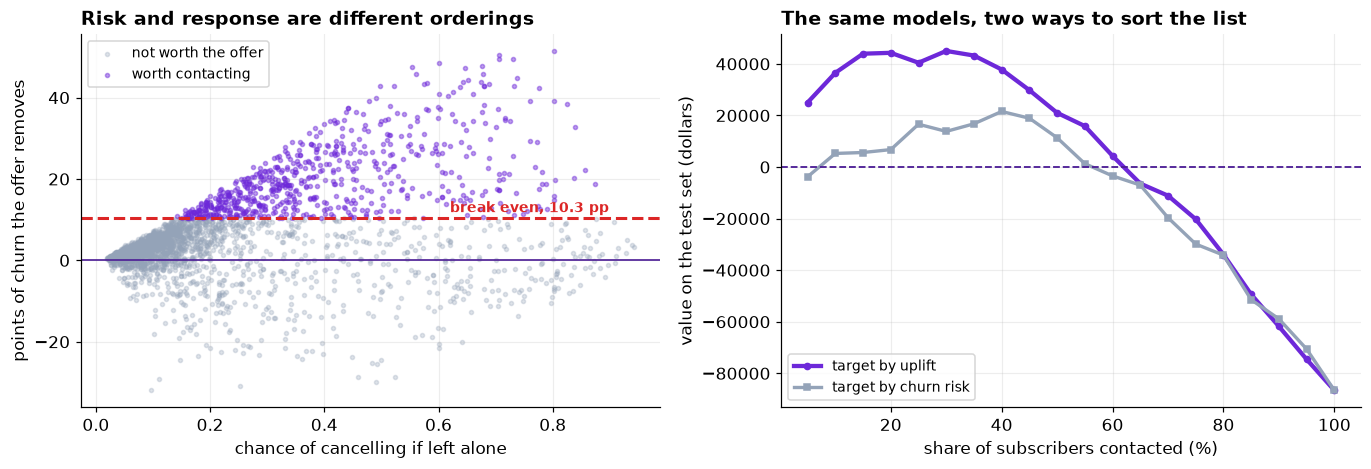

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12.6, 4.4))

be = OFFER/MARGIN
ax = axes[0]
sub = np.random.default_rng(2).choice(len(risk), 3000, replace=False)
good = uplift[sub] >= be
ax.scatter(risk[sub][~good], uplift[sub][~good]*100, s=7, alpha=0.30, color=MUT, label="not worth the offer")
ax.scatter(risk[sub][good],  uplift[sub][good]*100,  s=7, alpha=0.45, color=VI,  label="worth contacting")
ax.axhline(be*100, color=RD, lw=2, ls="--")
ax.axhline(0, color=DK, lw=1.1)
ax.text(0.62, be*100 + 1.5, "break even, 10.3 pp", color=RD, fontsize=9, fontweight="bold")
ax.set_xlabel("chance of cancelling if left alone")
ax.set_ylabel("points of churn the offer removes")
ax.set_title("Risk and response are different orderings")
ax.legend(fontsize=9, loc="upper left")

ax = axes[1]
ks = np.arange(5, 101, 5)
vr = [value_of(risk   >= np.quantile(risk,   1-k/100))[1] for k in ks]
vu = [value_of(uplift >= np.quantile(uplift, 1-k/100))[1] for k in ks]
ax.plot(ks, vu, color=VI, lw=2.8, marker="o", ms=4, label="target by uplift")
ax.plot(ks, vr, color=MUT, lw=2.2, marker="s", ms=3.5, label="target by churn risk")
ax.axhline(0, color=DK, lw=1.2, ls="--")
ax.set_xlabel("share of subscribers contacted (%)")
ax.set_ylabel("value on the test set (dollars)")
ax.set_title("The same models, two ways to sort the list")
ax.legend(fontsize=9, loc="lower left")
plt.tight_layout(); plt.show()

**Left:** if risk and response were the same thing this would be a diagonal band, and it is not. **Right:** every depth of the uplift-ranked list is worth more than the same depth of the risk-ranked one, and both go negative well before the whole base is contacted.

## Step 16 &middot; What this analysis cannot tell you

**The estimates are for this offer.** Everything measured here is the effect of 20 percent off three boxes. A phone call from a human, a free box, or an apology for a late delivery are different treatments and could easily have a positive effect on the group this one hurt.

**The uplift model is noisier than the risk model.** It is a difference between two predictions, so it carries both models' errors. That is why the quartile and segment tables above are measured against real randomized controls instead of being read off the model. Trust the measurement, use the model only to sort.

**The dormant finding is worth confirming before acting.** It is a subgroup analysis, the interval is wide, and it is the sort of result that should be checked with a small holdout next quarter rather than built into a permanent exclusion rule.

**Nothing here says the delivery failures do not matter.** They are the strongest predictor of churn in the dataset, and the fact that a discount does not fix them is a finding about discounts. Fixing the deliveries is a different project with a much larger prize.

---

### What to take away

1. **Three model families, a spread of 0.0009 in AUC.** The bake-off was the least consequential decision in the project.
2. **A SHAP importance is a property of the model, not of the world.** Drop a correlated column and a feature moves five places while the model gets no worse.
3. **SHAP and LIME name a different top driver for about half of the mid-risk subscribers.** Both are describing the model.
4. **Risk and uplift correlate at 0.34.** They are different orderings and the business decision needs the second one.
5. **Sorting by uplift instead of risk was worth roughly twice the money**, from the same data and the same models.
6. **The highest-risk segment loses money when targeted, and one segment is actively harmed by contact.** Neither fact is visible to a model that only predicts who leaves.